# Customer Churn & Retention Analytics — Dataset & EDA

This notebook walks through **understanding the dataset** and **Exploratory Data Analysis (EDA)**.
Training lives in `src/train.py` (run `python -m src.train`); the last section of this notebook loads the trained model and makes a prediction.

All plotting code is in `src/eda.py`, so the notebook and the scripts produce exactly the same figures.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.insert(0, os.path.abspath(".."))   # so `import src...` works from notebooks/

import pandas as pd
from IPython.display import Image, display
from src import eda
from src.data_loader import load_raw_data, clean_data, describe_dataset, FIGURES_DIR

pd.set_option("display.max_columns", 30)

## 1. Load the raw data

In [2]:
raw = load_raw_data()
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
describe_dataset(raw)

Shape (rows, columns): (7043, 21)

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values per column (NaN):
 Series([], dtype: int64)
Blank strings in TotalCharges: 11

Duplicate rows (all columns): 0
Duplicate rows ignoring customerID: 22

Class distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class distribution (%):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Observations**
- 7,043 customers, 21 columns (19 features + `customerID` + target `Churn`).
- `TotalCharges` is read as **text**, not a number, because 11 rows contain a blank `" "`. `isna()` shows 0 missing values — the missing values are *hidden* as blanks.
- No exact duplicate rows. 22 rows are identical if we ignore `customerID`, but they are **different customers** with the same profile, so they are kept.
- Class imbalance: ~73.5% stayed, ~26.5% churned.

## 2. Clean (leakage-free steps only)

In [4]:
df = clean_data(raw)
print(df.shape)
print(df.isna().sum()[df.isna().sum() > 0])
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Contract"]]

(7043, 20)
TotalCharges    11
dtype: int64


,tenure,MonthlyCharges,TotalCharges,Contract
488,0,52.55,NaN,Two year
753,0,20.25,NaN,Two year
936,0,80.85,NaN,Two year
1082,0,25.75,NaN,Two year
1340,0,56.05,NaN,Two year
3331,0,19.85,NaN,Two year
3826,0,25.35,NaN,Two year
4380,0,20.00,NaN,Two year
5218,0,19.70,NaN,One year
6670,0,73.35,NaN,Two year


All 11 customers with missing `TotalCharges` have `tenure = 0` — they are brand-new and have not been billed yet.
We do **not** fill them here. They are filled by `SimpleImputer(strategy="median")` inside the Scikit-learn pipeline, which learns the median from the training set only.
(Filling them with 0 would also be logically defensible — it is only 11 of 7,043 rows, so the choice has negligible effect.)

## 3. EDA
Each function below saves a figure to `reports/figures/` and returns the numbers behind it.

### 3.1 Churn distribution

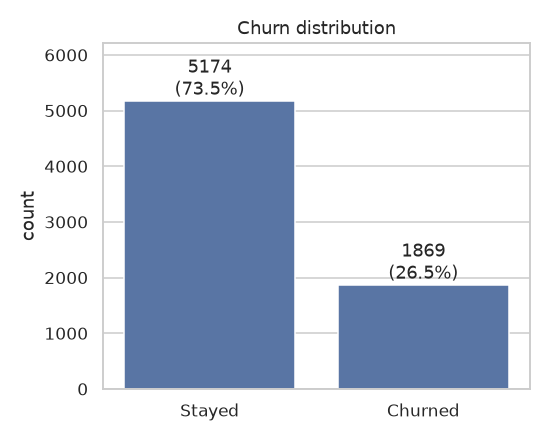

In [5]:
eda.plot_churn_distribution(df)
display(Image(filename=str(FIGURES_DIR / '01_churn_distribution.png')))

- **What it shows:** how many customers stayed vs churned.
- **Why:** to detect class imbalance before modelling.
- **Conclusion:** 26.5% churn. A model that always says "No churn" gets **73.5% accuracy** while catching zero churners — so accuracy alone is misleading. We handle this with class weights and judge the model with recall, precision, F1 and ROC-AUC.

### 3.2 Churn vs contract type

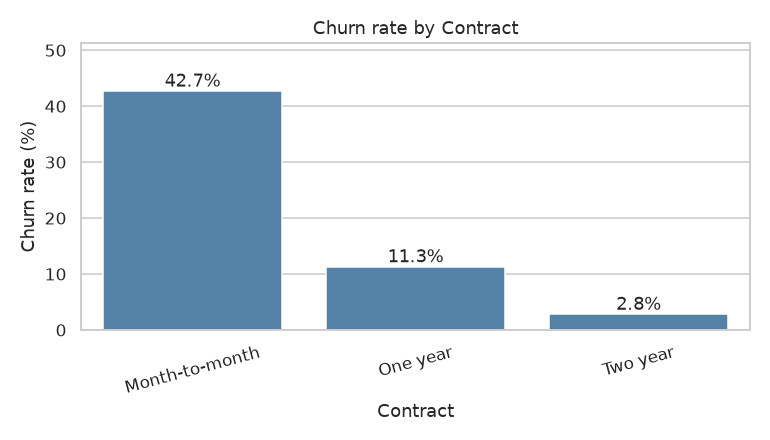

In [6]:
eda.plot_churn_rate_by_category(df, "Contract", "02_churn_vs_contract.png")
display(Image(filename=str(FIGURES_DIR / '02_churn_vs_contract.png')))

- **What it shows:** churn rate (%) inside each contract type.
- **Why:** contract length is the business's main lock-in lever.
- **Conclusion:** Month-to-month customers churn at **42.7%**, one-year at **11.3%**, two-year at **2.8%**. Contract type is one of the strongest churn signals.

### 3.3 Churn vs tenure

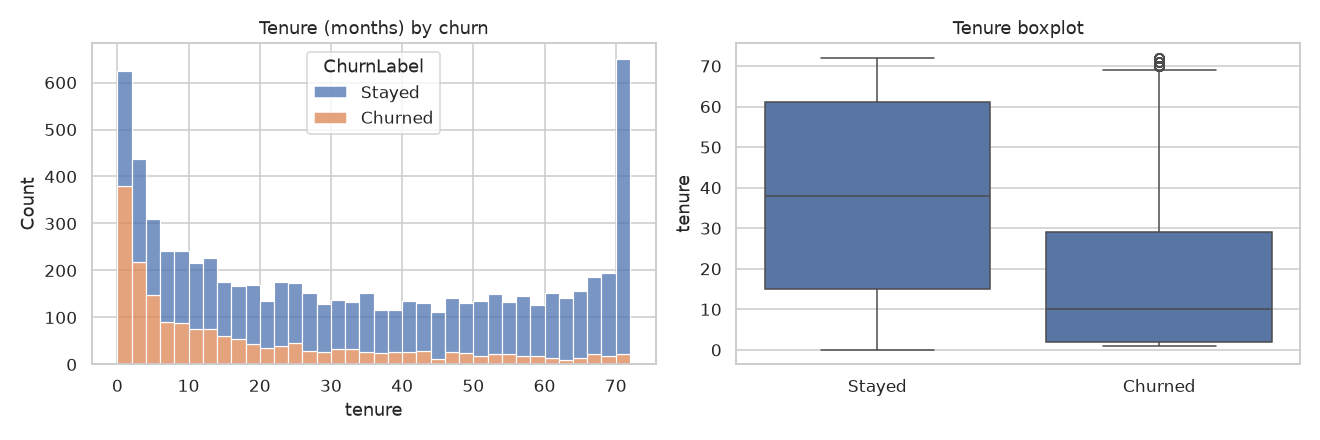

In [7]:
eda.plot_tenure(df)
display(Image(filename=str(FIGURES_DIR / '03_churn_vs_tenure.png')))

- **What it shows:** histogram + boxplot of tenure (months with the company), split by churn.
- **Why:** to see *when* customers leave.
- **Conclusion:** churners have a median tenure of **10 months** vs **38 months** for customers who stayed. Churn rate is **47.4%** in the first year and **9.5%** after 4 years. The first 12 months are the danger zone. (Outlier dots in the churned boxplot are long-tenure customers who still left.)

### 3.4 Churn vs monthly charges

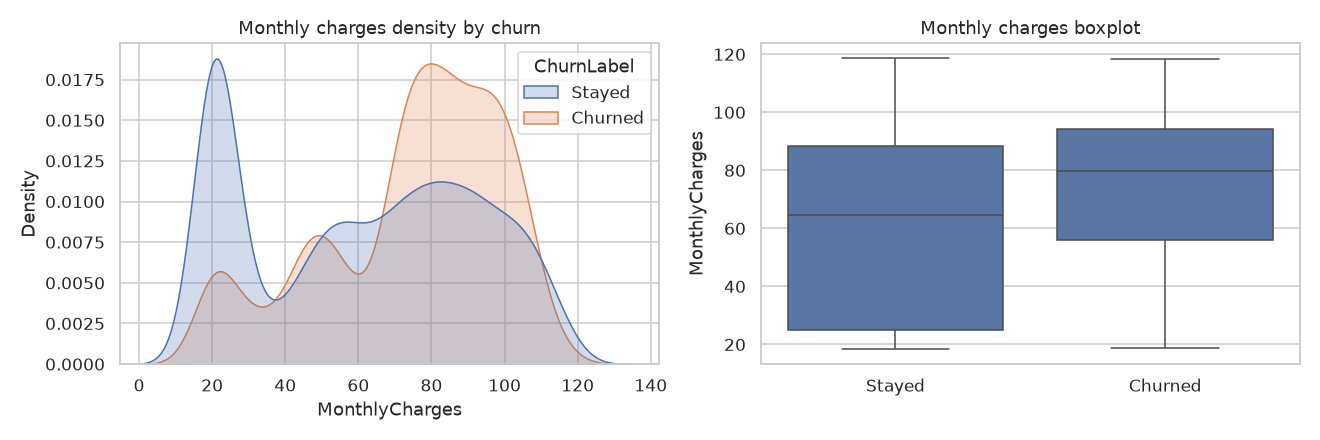

In [8]:
eda.plot_monthly_charges(df)
display(Image(filename=str(FIGURES_DIR / '04_churn_vs_monthly_charges.png')))

- **What it shows:** distribution of monthly bill for churners vs non-churners.
- **Why:** to check whether price drives churn.
- **Conclusion:** median monthly charge is **79.65** for churners vs **64.43** for non-churners. Churn is concentrated in the ~70–105 range (mostly fiber-optic plans). Note: many non-churners also pay ~20 (no-internet plans), which is why the 'Stayed' density has a peak at the low end.

### 3.5 Churn vs payment method

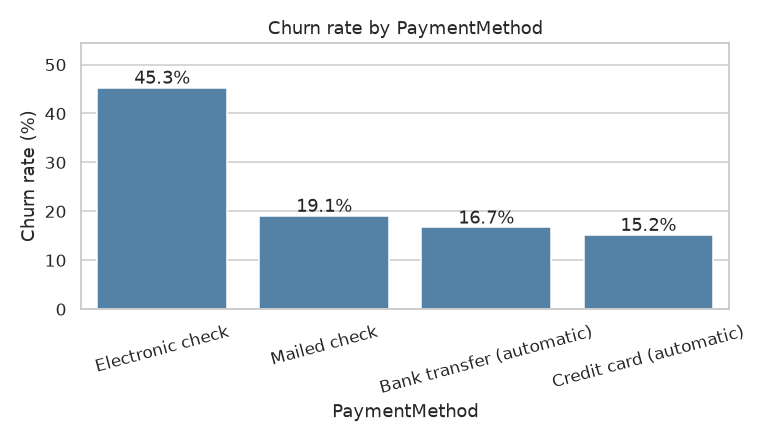

In [9]:
eda.plot_churn_rate_by_category(df, "PaymentMethod", "05_churn_vs_payment_method.png")
display(Image(filename=str(FIGURES_DIR / '05_churn_vs_payment_method.png')))

- **What it shows:** churn rate per payment method.
- **Why:** payment friction/commitment may relate to churn.
- **Conclusion:** electronic-check users churn at **45.3%**, vs 15–19% for the other methods. Automatic payments are associated with lower churn. **Association, not causation** — electronic check users are also more often month-to-month.

### 3.6 Total charges boxplot

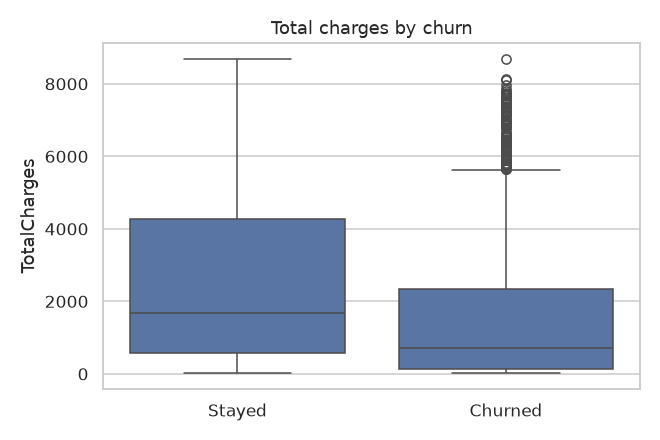

In [10]:
eda.plot_total_charges(df)
display(Image(filename=str(FIGURES_DIR / '06_churn_vs_total_charges.png')))

- **What it shows:** total amount billed so far, by churn.
- **Why:** checks the combined effect of tenure and price.
- **Conclusion:** churners have *lower* total charges (median 703.55 vs 1683.60) — not because they pay less per month (they pay more), but because they leave early. TotalCharges ≈ tenure × MonthlyCharges.

### 3.7 Correlation heatmap

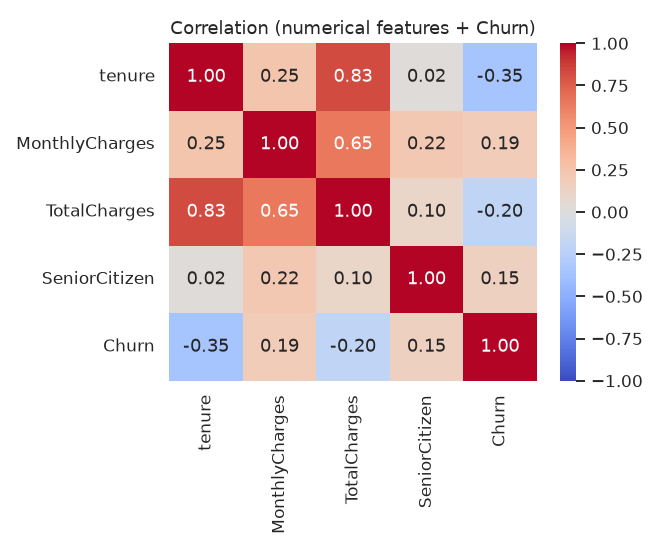

In [11]:
eda.plot_correlation_heatmap(df)
display(Image(filename=str(FIGURES_DIR / '07_correlation_heatmap.png')))

- **What it shows:** Pearson correlation between the numerical columns and Churn (0/1).
- **Why:** to measure linear relationships and spot redundant features.
- **Conclusion:** tenure vs Churn = **−0.35** (longer tenure → less churn), MonthlyCharges vs Churn = **+0.19**, TotalCharges vs Churn = **−0.20**. TotalCharges is strongly correlated with tenure (**0.83**) — partly redundant. Correlation only captures *linear* relationships, and correlation with a binary target is a rough indicator, not proof of cause.

### 3.8 Churn vs services

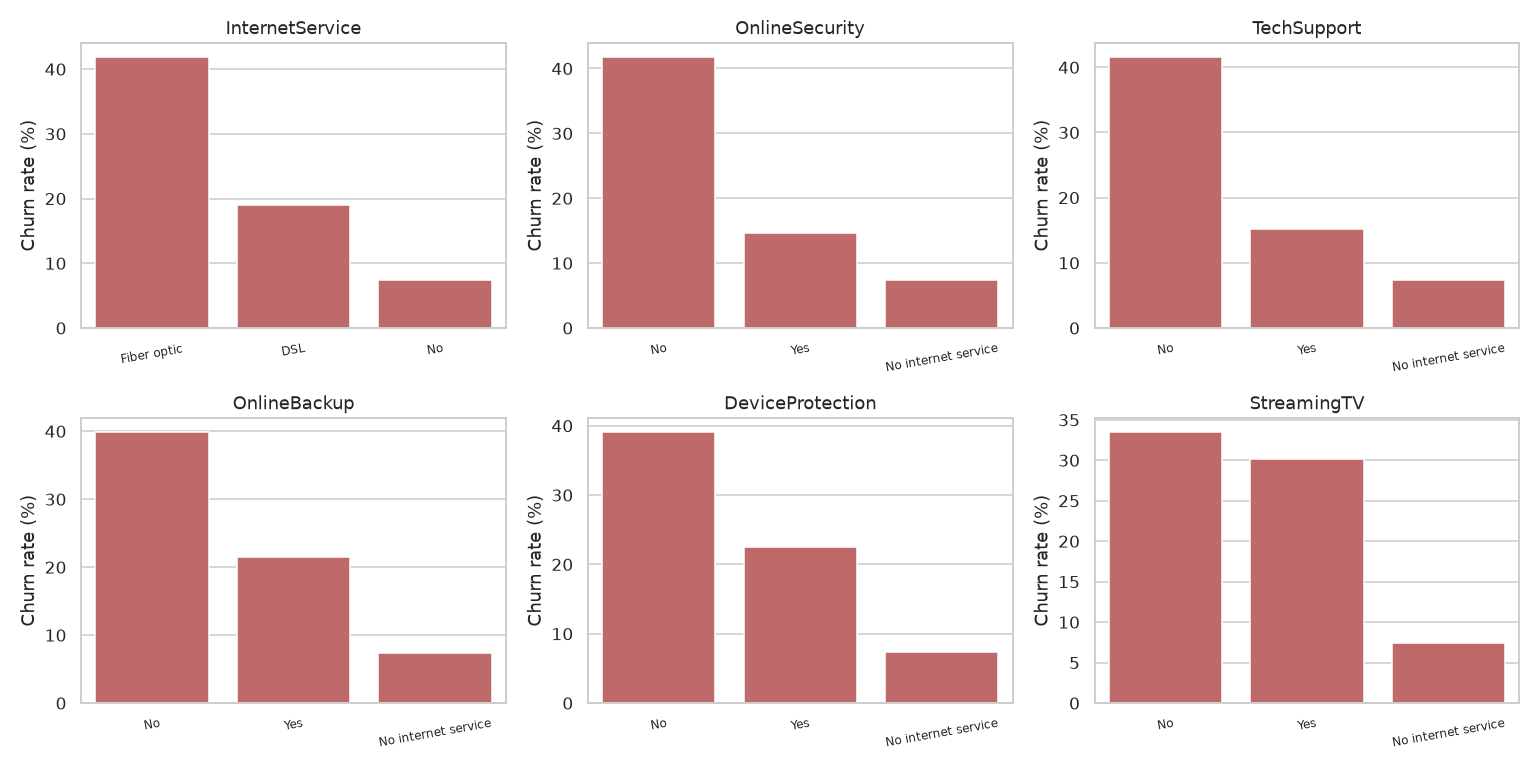

In [12]:
eda.plot_services(df)
display(Image(filename=str(FIGURES_DIR / '08_churn_vs_services.png')))

- **What it shows:** churn rate for each add-on service.
- **Why:** to see whether support/security services are linked to retention.
- **Conclusion:** fiber-optic customers churn at **41.9%** (vs 19.0% DSL). Customers *without* OnlineSecurity (41.8%) or TechSupport (41.6%) churn far more than those with them (~15%). Streaming services make little difference (33.5% vs 30.1%). Customers with no internet churn least (7.4%).

### EDA summary
Highest-risk profile: **new (tenure < 12 months), month-to-month contract, fiber-optic internet, no tech support / online security, paying by electronic check, high monthly bill.**
These findings guided the feature set and give the business concrete retention levers (contract upgrades, onboarding in year one, bundling tech support).

## 4. Prediction with the trained model
Requires `python -m src.train` to have been run (the repo ships the trained files in `models/`).

In [13]:
from src.predict import predict_churn

customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes",
    "StreamingMovies": "Yes", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check", "MonthlyCharges": 95.70, "TotalCharges": 191.40,
}
prob, cls = predict_churn(customer)
print(f"Customer has {prob:.0%} probability of churn. Predicted class: {cls}")

I0000 00:00:1790520757.159684    2009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790520758.723079    2009 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Customer has 93% probability of churn. Predicted class: 1
